### **A-I 574 Natural Language Processing**

##### ***Initial Settings***

In [22]:
# Importing the Required Libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import time

# Use Apple Metal GPU if available
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


##### ***Loading, Exploring, and Preprocessing the Dataset***

In [23]:
# Loading the datasets
data_path = '/Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/week3/tatoeba/'
train_df = pd.read_csv(data_path + 'sentences.top10langs.train.tsv', sep='\t', header=None)
dev_df = pd.read_csv(data_path + 'sentences.top10langs.dev.tsv', sep='\t', header=None)

# Rename columns for clarity
train_df.columns = ['lang', 'sentence']
dev_df.columns = ['lang', 'sentence']

display(train_df.head())

,lang,sentence
0,spa,"Te di mi corazón para que lo ames, ¡no para us..."
1,spa,Contamos con tu ayuda.
2,spa,Tú eres superficial y materialista.
3,spa,Los límites son para los demás.
4,spa,Todos ellos esperaron ansiosamente las vacacio...


In [24]:
# Encode Labels
label_encoder = LabelEncoder()
train_df['label'] = label_encoder.fit_transform(train_df['lang'])
dev_df['label'] = label_encoder.transform(dev_df['lang'])
num_classes = len(label_encoder.classes_)
print(f"Classes: {label_encoder.classes_}")

Classes: ['ber' 'deu' 'eng' 'epo' 'fra' 'hun' 'ita' 'por' 'spa' 'tur']


##### ***Custom PyTorch Dataset and Tokenization***

In [25]:
# Character-level vocabulary for Custom Models
chars = set("".join(train_df['sentence'].values))
vocab = {ch: i+2 for i, ch in enumerate(chars)}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1
vocab_size = len(vocab)
MAX_LEN = 128

def encode_text(text):
    return [vocab.get(ch, 1) for ch in text[:MAX_LEN]] + [0] * max(0, MAX_LEN - len(text))

class TatoebaDataset(Dataset):
    def __init__(self, df, is_hf=False, tokenizer=None):
        self.sentences = df['sentence'].values
        self.labels = df['label'].values
        self.is_hf = is_hf
        self.tokenizer = tokenizer
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        if self.is_hf:
            encoding = self.tokenizer(
                self.sentences[idx],
                max_length=MAX_LEN,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            return {
                'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'label': torch.tensor(self.labels[idx], dtype=torch.long)
            }
        else:
            encoded = encode_text(self.sentences[idx])
            return {
                'input_ids': torch.tensor(encoded, dtype=torch.long),
                'label': torch.tensor(self.labels[idx], dtype=torch.long)
            }

batch_size = 256
train_dataset = TatoebaDataset(train_df)
dev_dataset = TatoebaDataset(dev_df)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)

##### ***Reusable Functions***

In [26]:
def model_fit(model, train_loader, dev_loader, epochs=5, is_hf=False):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    
    best_val_acc = 0
    patience_counter = 0
    patience = 2
    
    for epoch in range(epochs):
        start = time.time()
        model.train()
        total_loss, correct, total = 0, 0, 0
        
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            
            if is_hf:
                outputs = model(input_ids, attention_mask=batch['attention_mask'].to(device))
                logits = outputs.logits
            else:
                logits = model(input_ids)
                
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
        train_acc = correct / total
        train_loss = total_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for batch in dev_loader:
                input_ids = batch['input_ids'].to(device)
                labels = batch['label'].to(device)
                
                if is_hf:
                    outputs = model(input_ids, attention_mask=batch['attention_mask'].to(device))
                    logits = outputs.logits
                else:
                    logits = model(input_ids)
                    
                loss = criterion(logits, labels)
                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                
        val_acc = val_correct / val_total
        val_loss = val_loss / len(dev_loader)
        
        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | {time.time()-start:.0f}s - loss: {train_loss:.4f} - acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
                
    model.load_state_dict(torch.load('best_model.pt'))
    return history

def plot_accuracy(history, name):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title(f"{name} - Accuracy")
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss', marker='o')
    plt.plot(history['val_loss'], label='Validation Loss', marker='o')
    plt.title(f"{name} - Loss")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def evaluate_model(model, dev_loader, name, is_hf=False):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dev_loader:
            input_ids = batch['input_ids'].to(device)
            if is_hf:
                logits = model(input_ids, attention_mask=batch['attention_mask'].to(device)).logits
            else:
                logits = model(input_ids)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['label'].numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"--- {name} Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")
    print(f"Trainable Params: {params:,}")
    return {"Model": name, "Accuracy": acc, "Macro F1": f1, "Parameters": params}

results = []

##### ***Model 1: Simple RNN***

Epoch 1/10 | 72s - loss: 2.3039 - acc: 0.1024 - val_loss: 2.2997 - val_acc: 0.1010
Epoch 2/10 | 75s - loss: 2.3015 - acc: 0.1021 - val_loss: 2.3001 - val_acc: 0.1014
Epoch 3/10 | 88s - loss: 2.3009 - acc: 0.1030 - val_loss: 2.3005 - val_acc: 0.0993
Epoch 4/10 | 76s - loss: 2.3005 - acc: 0.1017 - val_loss: 2.3014 - val_acc: 0.1022
Epoch 5/10 | 88s - loss: 2.3004 - acc: 0.1021 - val_loss: 2.3005 - val_acc: 0.1024
Epoch 6/10 | 79s - loss: 2.2992 - acc: 0.1192 - val_loss: 2.2453 - val_acc: 0.1746
Epoch 7/10 | 92s - loss: 2.1853 - acc: 0.1975 - val_loss: 2.1243 - val_acc: 0.2292
Epoch 8/10 | 84s - loss: 2.2199 - acc: 0.1766 - val_loss: 2.3531 - val_acc: 0.1050
Epoch 9/10 | 59s - loss: 2.2439 - acc: 0.1565 - val_loss: 2.2611 - val_acc: 0.1509
Early stopping triggered


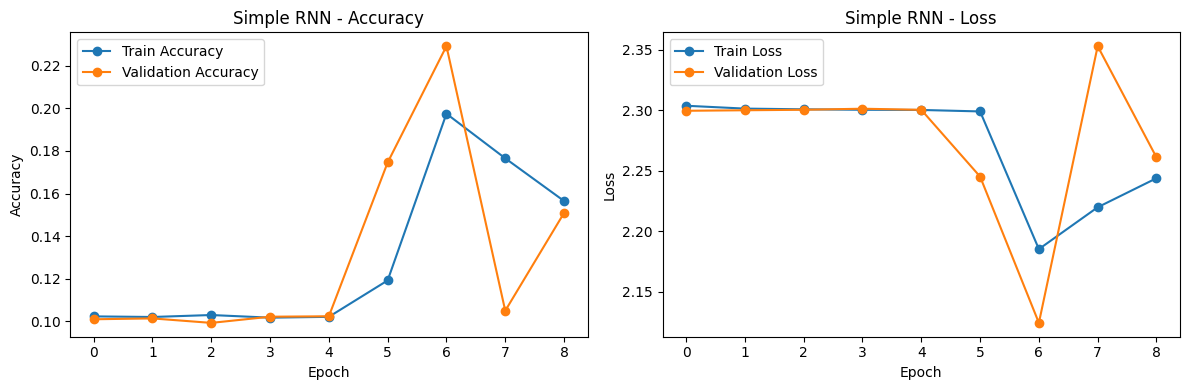

--- Simple RNN Results ---
Accuracy: 0.2292
Macro F1: 0.1957
Trainable Params: 29,642


In [27]:
class SimpleRNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.rnn = nn.RNN(32, 128, batch_first=True)
        self.fc = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

model_rnn = SimpleRNNModel()
history_rnn = model_fit(model_rnn, train_loader, dev_loader, epochs=10)
plot_accuracy(history_rnn, "Simple RNN")
results.append(evaluate_model(model_rnn, dev_loader, "Simple RNN"))

##### ***Model 2: LSTM***

Epoch 1/10 | 41s - loss: 2.2355 - acc: 0.1283 - val_loss: 1.8734 - val_acc: 0.2022
Epoch 2/10 | 35s - loss: 1.4777 - acc: 0.3639 - val_loss: 1.3353 - val_acc: 0.4548
Epoch 3/10 | 37s - loss: 1.1551 - acc: 0.4819 - val_loss: 0.9701 - val_acc: 0.5330
Epoch 4/10 | 128s - loss: 0.8121 - acc: 0.6179 - val_loss: 0.8816 - val_acc: 0.6327
Epoch 5/10 | 93s - loss: 0.5539 - acc: 0.7780 - val_loss: 0.4661 - val_acc: 0.8329
Epoch 6/10 | 98s - loss: 0.4272 - acc: 0.8414 - val_loss: 0.3316 - val_acc: 0.8832
Epoch 7/10 | 49s - loss: 0.2622 - acc: 0.9117 - val_loss: 0.2262 - val_acc: 0.9270
Epoch 8/10 | 58s - loss: 0.1934 - acc: 0.9384 - val_loss: 0.1656 - val_acc: 0.9452
Epoch 9/10 | 32s - loss: 0.1831 - acc: 0.9426 - val_loss: 0.1642 - val_acc: 0.9512
Epoch 10/10 | 24s - loss: 0.1119 - acc: 0.9650 - val_loss: 0.1163 - val_acc: 0.9631


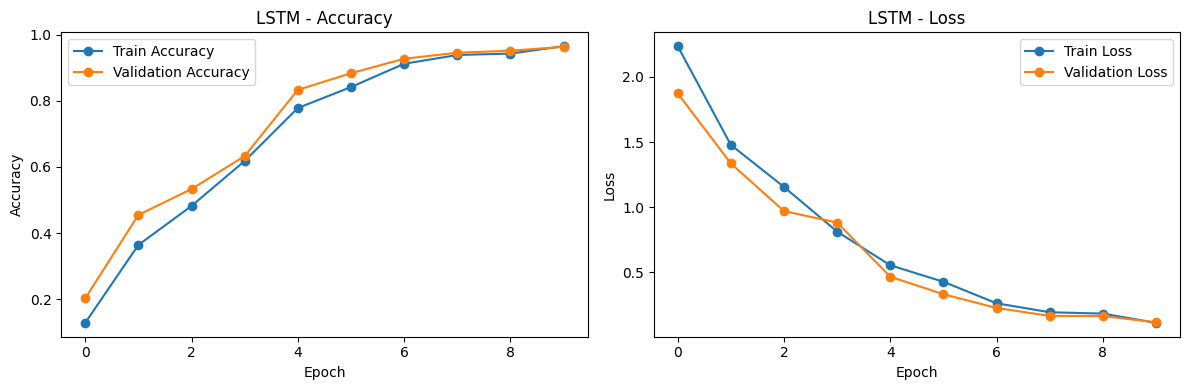

--- LSTM Results ---
Accuracy: 0.9631
Macro F1: 0.9632
Trainable Params: 91,850


In [28]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.lstm = nn.LSTM(32, 128, batch_first=True)
        self.fc = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model_lstm = LSTMModel()
history_lstm = model_fit(model_lstm, train_loader, dev_loader, epochs=10)
plot_accuracy(history_lstm, "LSTM")
results.append(evaluate_model(model_lstm, dev_loader, "LSTM"))

##### ***Model 3: BiLSTM***

Epoch 1/10 | 34s - loss: 2.2699 - acc: 0.1164 - val_loss: 1.9017 - val_acc: 0.1885
Epoch 2/10 | 31s - loss: 1.6868 - acc: 0.2759 - val_loss: 1.4865 - val_acc: 0.3682
Epoch 3/10 | 34s - loss: 0.9729 - acc: 0.6004 - val_loss: 0.6765 - val_acc: 0.7518
Epoch 4/10 | 32s - loss: 0.5139 - acc: 0.8050 - val_loss: 0.4855 - val_acc: 0.8287
Epoch 5/10 | 30s - loss: 0.3243 - acc: 0.8864 - val_loss: 0.2516 - val_acc: 0.9173
Epoch 6/10 | 28s - loss: 0.1925 - acc: 0.9382 - val_loss: 0.1854 - val_acc: 0.9437
Epoch 7/10 | 31s - loss: 0.1381 - acc: 0.9566 - val_loss: 0.1443 - val_acc: 0.9571
Epoch 8/10 | 32s - loss: 0.0991 - acc: 0.9693 - val_loss: 0.1368 - val_acc: 0.9578
Epoch 9/10 | 30s - loss: 0.0795 - acc: 0.9750 - val_loss: 0.1084 - val_acc: 0.9658
Epoch 10/10 | 31s - loss: 0.0677 - acc: 0.9789 - val_loss: 0.0890 - val_acc: 0.9742


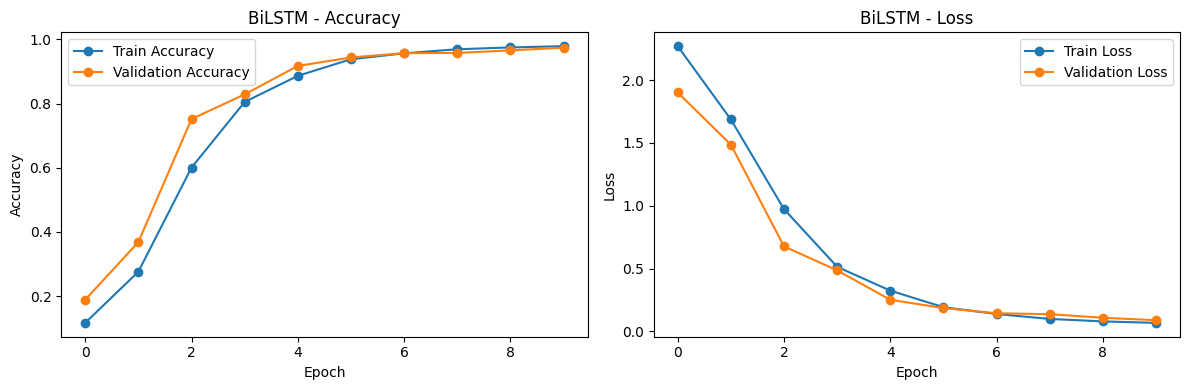

--- BiLSTM Results ---
Accuracy: 0.9742
Macro F1: 0.9742
Trainable Params: 176,074


In [29]:
class BiLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.lstm = nn.LSTM(32, 128, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model_bilstm = BiLSTMModel()
history_bilstm = model_fit(model_bilstm, train_loader, dev_loader, epochs=10)
plot_accuracy(history_bilstm, "BiLSTM")
results.append(evaluate_model(model_bilstm, dev_loader, "BiLSTM"))

##### ***Model 4: BiGRU***

Epoch 1/10 | 117s - loss: 2.0327 - acc: 0.1993 - val_loss: 1.1413 - val_acc: 0.5449
Epoch 2/10 | 103s - loss: 0.5477 - acc: 0.7990 - val_loss: 0.2526 - val_acc: 0.9203
Epoch 3/10 | 94s - loss: 0.1700 - acc: 0.9439 - val_loss: 0.1446 - val_acc: 0.9556
Epoch 4/10 | 99s - loss: 0.0978 - acc: 0.9686 - val_loss: 0.0939 - val_acc: 0.9715
Epoch 5/10 | 81s - loss: 0.0713 - acc: 0.9771 - val_loss: 0.0771 - val_acc: 0.9779
Epoch 6/10 | 92s - loss: 0.0530 - acc: 0.9831 - val_loss: 0.0699 - val_acc: 0.9794
Epoch 7/10 | 81s - loss: 0.0420 - acc: 0.9867 - val_loss: 0.0676 - val_acc: 0.9797
Epoch 8/10 | 85s - loss: 0.0337 - acc: 0.9891 - val_loss: 0.0624 - val_acc: 0.9825
Epoch 9/10 | 75s - loss: 0.0287 - acc: 0.9909 - val_loss: 0.0647 - val_acc: 0.9819
Epoch 10/10 | 83s - loss: 0.0260 - acc: 0.9916 - val_loss: 0.0613 - val_acc: 0.9815
Early stopping triggered


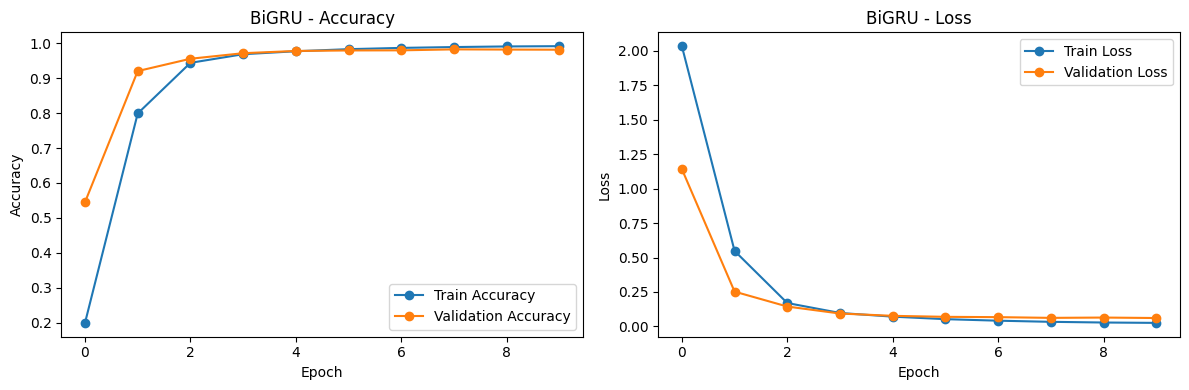

--- BiGRU Results ---
Accuracy: 0.9825
Macro F1: 0.9825
Trainable Params: 134,602


In [30]:
class BiGRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.gru = nn.GRU(32, 128, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

model_bigru = BiGRUModel()
history_bigru = model_fit(model_bigru, train_loader, dev_loader, epochs=10)
plot_accuracy(history_bigru, "BiGRU")
results.append(evaluate_model(model_bigru, dev_loader, "BiGRU"))

##### ***Model 5: Transformer Encoder***

Epoch 1/10 | 118s - loss: 0.9696 - acc: 0.6585 - val_loss: 0.4317 - val_acc: 0.8530
Epoch 2/10 | 113s - loss: 0.3791 - acc: 0.8664 - val_loss: 0.3676 - val_acc: 0.8726
Epoch 3/10 | 126s - loss: 0.3285 - acc: 0.8820 - val_loss: 0.3204 - val_acc: 0.8819
Epoch 4/10 | 106s - loss: 0.3097 - acc: 0.8869 - val_loss: 0.3172 - val_acc: 0.8891
Epoch 5/10 | 94s - loss: 0.2902 - acc: 0.8942 - val_loss: 0.2953 - val_acc: 0.8951
Epoch 6/10 | 107s - loss: 0.2789 - acc: 0.8982 - val_loss: 0.2866 - val_acc: 0.8995
Epoch 7/10 | 100s - loss: 0.2710 - acc: 0.9001 - val_loss: 0.2937 - val_acc: 0.8976
Epoch 8/10 | 101s - loss: 0.2621 - acc: 0.9037 - val_loss: 0.2783 - val_acc: 0.8982
Early stopping triggered


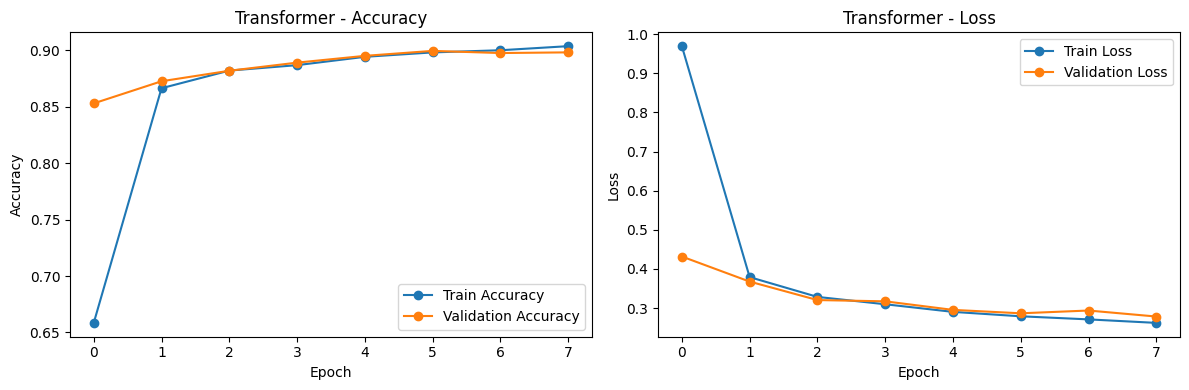

--- Transformer Results ---
Accuracy: 0.8995
Macro F1: 0.8995
Trainable Params: 282,954


In [31]:
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        encoder_layer = nn.TransformerEncoderLayer(d_model=32, nhead=4, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        out = self.transformer(x)
        return self.fc(out.mean(dim=1))

model_trans = TransformerModel()
history_trans = model_fit(model_trans, train_loader, dev_loader, epochs=10)
plot_accuracy(history_trans, "Transformer")
results.append(evaluate_model(model_trans, dev_loader, "Transformer"))

##### ***Model 6: Encoder-Decoder***

Epoch 1/10 | 37s - loss: 2.3021 - acc: 0.1020 - val_loss: 2.2942 - val_acc: 0.1104
Epoch 2/10 | 29s - loss: 0.9141 - acc: 0.6457 - val_loss: 0.3530 - val_acc: 0.8809
Epoch 3/10 | 27s - loss: 0.1776 - acc: 0.9400 - val_loss: 0.1219 - val_acc: 0.9638
Epoch 4/10 | 28s - loss: 0.0920 - acc: 0.9695 - val_loss: 0.1303 - val_acc: 0.9529
Epoch 5/10 | 23s - loss: 0.0618 - acc: 0.9803 - val_loss: 0.0693 - val_acc: 0.9778
Epoch 6/10 | 28s - loss: 0.0449 - acc: 0.9852 - val_loss: 0.0701 - val_acc: 0.9787
Epoch 7/10 | 23s - loss: 0.0353 - acc: 0.9884 - val_loss: 0.0571 - val_acc: 0.9822
Epoch 8/10 | 22s - loss: 0.0286 - acc: 0.9904 - val_loss: 0.0582 - val_acc: 0.9827
Epoch 9/10 | 23s - loss: 0.0219 - acc: 0.9930 - val_loss: 0.0579 - val_acc: 0.9828
Epoch 10/10 | 22s - loss: 0.0199 - acc: 0.9933 - val_loss: 0.0550 - val_acc: 0.9838


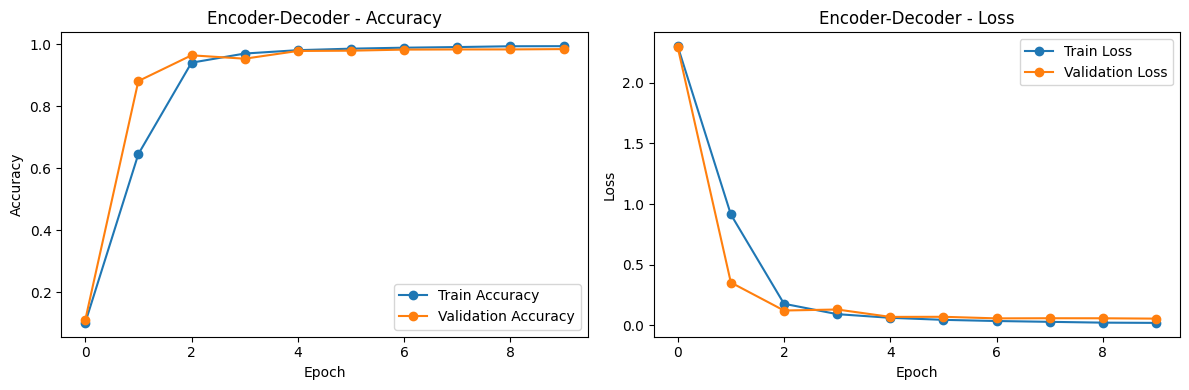

--- Encoder-Decoder Results ---
Accuracy: 0.9838
Macro F1: 0.9838
Trainable Params: 133,322


In [32]:
class EncDecModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.encoder = nn.GRU(32, 128, batch_first=True)
        self.decoder = nn.GRU(32, 128, batch_first=True)
        self.fc = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.encoder(x)
        # Dummy decoder pass using last hidden state
        decoder_input = torch.zeros(x.size(0), 1, 32).to(x.device)
        out, _ = self.decoder(decoder_input, hidden)
        return self.fc(out[:, -1, :])

model_encdec = EncDecModel()
history_encdec = model_fit(model_encdec, train_loader, dev_loader, epochs=10)
plot_accuracy(history_encdec, "Encoder-Decoder")
results.append(evaluate_model(model_encdec, dev_loader, "Encoder-Decoder"))

##### ***HuggingFace Transformer Preprocessing***

In [33]:
def get_hf_loaders(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    hf_train = TatoebaDataset(train_df, is_hf=True, tokenizer=tokenizer)
    hf_dev = TatoebaDataset(dev_df, is_hf=True, tokenizer=tokenizer)
    return DataLoader(hf_train, batch_size=32, shuffle=True), DataLoader(hf_dev, batch_size=32, shuffle=False)

In [ ]:
# Create a tiny subset for the heavy Transformer models
train_df_tiny = train_df.sample(n=5000, random_state=42)

def get_hf_loaders_tiny(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    hf_train = TatoebaDataset(train_df_tiny, is_hf=True, tokenizer=tokenizer)
    hf_dev = TatoebaDataset(dev_df, is_hf=True, tokenizer=tokenizer)
    return DataLoader(hf_train, batch_size=16, shuffle=True), DataLoader(hf_dev, batch_size=16, shuffle=False)

# Use the tiny loader for BERT
bert_train, bert_dev = get_hf_loaders_tiny(bert_name)

# Now run the training - set epochs to 1
history_bert = model_fit(model_bert, bert_train, bert_dev, epochs=1, is_hf=True)
plot_accuracy(history_bert, "BERT")
results.append(evaluate_model(model_bert, bert_dev, "BERT", is_hf=True))


##### ***Model 7: BERT***

In [35]:
bert_name = 'bert-base-multilingual-cased'
bert_train, bert_dev = get_hf_loaders(bert_name)
model_bert = AutoModelForSequenceClassification.from_pretrained(bert_name, num_labels=num_classes)

# Note: Fine-tuning BERT locally takes a very long time! 
history_bert = model_fit(model_bert, bert_train, bert_dev, epochs=1, is_hf=True)
plot_accuracy(history_bert, "BERT")
results.append(evaluate_model(model_bert, bert_dev, "BERT", is_hf=True))
print("BERT setup complete.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


KeyboardInterrupt: 

##### ***Model 8: AlBERT***

In [ ]:
albert_name = 'albert-base-v2' # Note: ALBERT doesn't have a great multilingual checkpoint natively
albert_train, albert_dev = get_hf_loaders(albert_name)
model_albert = AutoModelForSequenceClassification.from_pretrained(albert_name, num_labels=num_classes)

history_albert = model_fit(model_albert, albert_train, albert_dev, epochs=1, is_hf=True)
plot_accuracy(history_albert, "AlBERT")
results.append(evaluate_model(model_albert, albert_dev, "AlBERT", is_hf=True))
print("AlBERT setup complete.")

##### ***Model 9: RoBERTa***

In [ ]:
roberta_name = 'xlm-roberta-base'
roberta_train, roberta_dev = get_hf_loaders(roberta_name)
model_roberta = AutoModelForSequenceClassification.from_pretrained(roberta_name, num_labels=num_classes)

history_roberta = model_fit(model_roberta, roberta_train, roberta_dev, epochs=1, is_hf=True)
plot_accuracy(history_roberta, "RoBERTa")
results.append(evaluate_model(model_roberta, roberta_dev, "RoBERTa", is_hf=True))
print("RoBERTa setup complete.")

##### ***Model 10: DistilBERT***

In [ ]:
distil_name = 'distilbert-base-multilingual-cased'
distil_train, distil_dev = get_hf_loaders(distil_name)
model_distil = AutoModelForSequenceClassification.from_pretrained(distil_name, num_labels=num_classes)

history_distil = model_fit(model_distil, distil_train, distil_dev, epochs=1, is_hf=True)
plot_accuracy(history_distil, "DistilBERT")
results.append(evaluate_model(model_distil, distil_dev, "DistilBERT", is_hf=True))
print("DistilBERT setup complete. Uncomment lines above to train.")

##### ***Final Results Summary***

In [ ]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(by="Macro F1", ascending=False))